## Topic Analysis Notebook

### Load Data and Extract Features

In [1]:
### Imports
import matplotlib.pyplot as plt

EXPNAME = "secondExp"    # Name of the ERxperiment in Quesion


### Parameters and Globals
CLASSN = 4                       # Number of MW Discrete Classess - Use it to 4 - easier for now, most measures can be aggregated later
DATAFOLDER = "data_second"       # Data Folder for experiment
LABELING = False                 # Labeling Mode
CLASSESS =  {1:"Focus",          # Classess Dictionairy to understand what means what
             2:"Task-Related Thoughts", 
             3: "Mind Wandering",
             4: "Mind Wandering"}

CONTINUE = False   # Whether we want to ascribe NEW data to previous DataFrame or re-analyse them as they are 
VERBOSE = True     # Verbosity - How much of an output out of this analysis do we want?
LOADREADY = True   # Preffered Option - It loads already ready df_Data that was screened 
# FIlteri Data Parameters
SUBJECTS = "all"   # If we want to process all the subjects or single out in a list those that are to be removed - Default - ALL SUBJECTS
SHORTLEMMAS = True   # Whether to include Utterances that have simple to little Lemmas


VIZFOLDER = f"FINAL_extrF_{CLASSN}_{SHORTLEMMAS}_{SUBJECTS}"


In [2]:
####    Load Necessery Variables and Paths:
import os 
from storyTools import loadStory,splitStoryEntity,reLabel
import pandas as pd
import numpy as np 
import pickle

### General Working, Data, and Saving Path:
workingDir = os.getcwd();                                 # Current Folder
path = os.path.split(workingDir)[0] + "\\" + DATAFOLDER   # Data path
savePathRecall = os.path.join(workingDir,EXPNAME,'Recalls')       # Save Path for Recall results
savePathFeatures = os.path.join(workingDir,EXPNAME,'RecallAnalysis',VIZFOLDER)

if os.path.isdir(savePathFeatures) == 0:
    os.makedirs(savePathFeatures) # Create a directory for recall results

subjects = [f for f in os.listdir(path) if  not os.path.isfile(os.path.join(path, f))]  # get all the filenames


### Get Polish Stopwords:
with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
    polish_stopwords = set(line.strip().lower() for line in f if line.strip())


###  If We want to Continue giving new data and Not lto label we sfhall; use Topic Classifier to ascribe classess to the new Data: 
if CONTINUE and not LABELING:
    with open(os.path.join(workingDir,EXPNAME,"RecallAnalysis","topic_model_logreg.pkl"), "rb") as f:
        classifModel = pickle.load(f)

### Load Previous Excel File with Data:
dfData = pd.read_excel(os.path.join(savePathFeatures,"data.xlsx"), index_col=0)

### Create other Data Frames
#if not os.path.isfile(os.path.join(savePathFeatures,"features.xlsx")) or not CONTINUE:
dfAnalysis = dfData[['Subject','Fragment','Attention','utt_leng']] # Data Frame for Analysis

    

### Change Classess for a 2 way classification:
#### RE-Teaching on Binary Classification: 
if CLASSN == 2:
    dfData = reLabel(dfData,renameDict={1:1,1:2,3:3,3:4})
    dfData = reLabel(dfData,renameDict={1:1,2:3})
    CLASSESS =  {1:"Focus", 2:"Mind Wandering"}




c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
From c:\Users\barak\Documents\GitHub\startegicMW_lite\.venv\Lib\site-packages\tf_keras\src\losses.py:2976: The name tf.losses.sparse_softmax_cross_entropy is deprecated. Please use tf.compat.v1.losses.sparse_softmax_cross_entropy instead.



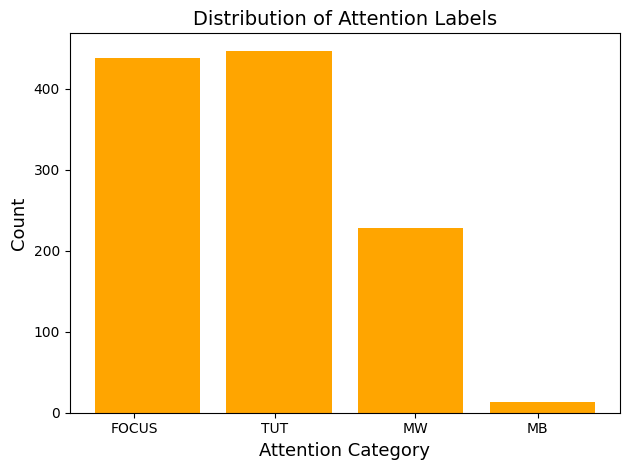

% of FOCUS: 0.39 (N: 438)
% of TRT:   0.40 (N: 446)
% of MW:    0.20 (N: 228)
% of MB:    0.01 (N: 13)


<Figure size 640x480 with 0 Axes>

In [3]:
import ast

if not LOADREADY:
    def fillDfData(dfData,savePathRecall):
        labeledSubjects = dfData['Subject'].unique()
        subjR = [ f.name for f in os.scandir(savePathRecall) if f.is_dir() ]

        from IPython.display import clear_output
        if LABELING:
            answer = []
            answDict = {}
            answrScheme = {v: k for k, v in CLASSESS.items()}

        subjList     = []
        fragmentList = []
        rawCorpus    = []
        answDict = {}
        answer = []

        for sn,s in enumerate(subjR):

            textfiles = [f for f in os.listdir(os.path.join(savePathRecall, s)) if f.endswith('.txt') and 'recall_' in f[:7] and "KASIA" not in f]
            answDict[s] = []
            if CONTINUE and (s in labeledSubjects): # Label only unlabeled Subjects - Creates a NEW DataFrame
                print(f"{s}: This Subject have been analysed already")
                continue
            
            for t in textfiles:
                text_file =  open(os.path.join(savePathRecall,s,t), "r+",encoding="utf-8")
                fragmentList.append(os.path.splitext(t)[0])
                subjList.append(s)

                
                for line in text_file: # One Text - One Line: Always! - thats why it worrks although it looks INCREDIBELY SKETCHY
                    rawCorpus.append(line) 
                    print(line)
                    if LABELING:
                        print(f"Text of {os.path.splitext(t)[0]} from {s}",flush=True)
                        print(line,flush=True)
                        ans = input()
                        answer.append(ans)
                        answDict[s].append(ans)
                        clear_output()
                    else:
                        if CONTINUE: # IF no labeling BUT continue, means that We need to fill by Blanks
                            answer.append(None)
                        else: # If No Labeling and No continue, we need to fill previous iteration from our DF
                            print(s,t)
                            if np.sum((dfData['Subject'] ==s) & (dfData['Fragment'] == os.path.splitext(t)[0])):
                                answer.append(dfData['Attention'][(dfData['Subject'] ==s) & (dfData['Fragment'] == os.path.splitext(t)[0])].values[0])
                            else:
                                answer.append(None)
        import pandas as pd
        if len(rawCorpus): #If there are  New Subjects
            dfData= pd.DataFrame([subjList,fragmentList,answer,rawCorpus],index = ["Subject","Fragment","Attention","Utterance"]).transpose()
            dfData['utt_leng'] = [len(t) for t in dfData['Utterance'].values]
            dfAnalysis = dfData[['Subject','Fragment','Attention','utt_leng']] # Data Frame for Analysis

        else:

            ### Change String into a list
            for cl in dfData.drop(columns=['Subject', 'Fragment','Utterance','Tracking','StoryFrag']).columns:
                if type(dfData[cl].values[0]) is str:
                    dfData[cl] = dfData[cl].apply(ast.literal_eval)
            rawCorpus =  list(dfData['Utterance'])

        return rawCorpus,dfData,dfAnalysis,subjList,fragmentList,labeledSubjects

    rawCorpus,dfData,dfAnalysis,subjList,fragmentList,labeledSubjects =  fillDfData(dfData,savePathRecall)
else:
    rawCorpus =  list(dfData['Utterance'])       # Corpus made from List of DS
    subjList = []                                # List of subjects FOR preprocessing - empty because we are only concerend with current subjects
    labeledSubjects = dfData['Subject'].unique() # all labeled subejcst
    fragmentList =  list(dfData['Fragment'])


### Plot of Attentional Distribution
if not np.sum(dfData['Attention'].isna()):
    plt.hist(dfData['Attention'], bins=4, rwidth=0.8, color="orange")

    # Custom tick labels centered on bins
    plt.xticks([1.3,2.1,2.9,3.6],labels=["FOCUS", "TUT", "MW", "MB"])

    # Add labels and title
    plt.xlabel("Attention Category", fontsize=13)
    plt.ylabel("Count", fontsize=13)
    plt.title("Distribution of Attention Labels", fontsize=14)

    plt.tight_layout()
    plt.show()
    plt.savefig(os.path.join(savePathFeatures,"attDist.png"))
    attGroups =  dfData.groupby('Attention')['Attention'].count()
    print(f"% of FOCUS: {attGroups.loc[1]/len(dfData):.2f} (N: {attGroups.loc[1]})")
    print(f"% of TRT:   {attGroups.loc[2]/len(dfData):.2f} (N: {attGroups.loc[2]})")

    print(f"% of MW:    {attGroups.loc[3]/len(dfData):.2f} (N: {attGroups.loc[3]})")
    print(f"% of MB:    {attGroups.loc[4]/len(dfData):.2f} (N: {attGroups.loc[4]})")

    # Create a df_analysis_check (Where the Average Differences in Features across Different Measures WIll be stored)
    df_Analysis_Checks = dfAnalysis.groupby("Attention")[['utt_leng']].agg(['min', 'max', 'mean', 'std']).transpose() # Attention 

    ### Create a df for Descritpive stats of Data :
    df_Subject_Checks = dfData.groupby(['Subject', 'Attention']).size().unstack(fill_value=0).astype(int) # Attention
    uttLeng = dfData.groupby("Subject")['utt_leng'].describe() ### Desciribe of Story Length
    df_Subject_Checks = pd.concat([df_Subject_Checks.astype(int), uttLeng], axis=1, keys=['Attention Desc', 'Utterance Leng Desc']).transpose()
    df_Subject_Checks

#### Extract Morphological Features From Texts

In [4]:
#### ---- SPACY BASED ------ #####

### Load Spacy Engine and Morfeusz!
import spacy
NLP = spacy.load("pl_core_news_lg")
from storyTools import spacyMorph
import morfeusz2
morf = morfeusz2.Morfeusz()


### Load Dictionairy Stemmer based on Morfeusz togeter with 
from storyTools import dictStemmer,lems,preNorm

all_Lemas = [];
all_Verb = [];
all_Noun = [];
all_Sentences = [];


for i,t in enumerate(dfData['Utterance']):

    ### Continiue if subject was already processed 
    if len(subjList) !=0:
        if CONTINUE and (subjList[i] in labeledSubjects):
            continue
    if VERBOSE:
        print(f"Processing: {dfData['Subject'].iloc[i]}//{dfData['Fragment'].iloc[i]}")

    ### Get rid of Empty Lemma:
    verb_phrases,noun_phrases,lemmas,sentences = spacyMorph(t,NLP,morf,polish_stopwords)
    lemmas    = list(filter(lambda a: a != ' ', lemmas))        # Filter out Empty Sequences
    sentences = list(filter(lambda a: a != ' ', sentences))     # Filter out Empty Sequences

    all_Sentences.append(sentences)
    all_Lemas.append(lemmas)
    all_Verb.append(verb_phrases)
    all_Noun.append(noun_phrases)


dfData['Sentences'] = all_Sentences;
dfData['Lemmas']    = all_Lemas;
dfData['Verbs']     = all_Verb;
dfData['Nouns']     = all_Noun;

#### Gathering ALL Lemmas in a single List
allLemas = []
for t in dfData['Lemmas'].values:  
    allLemas = allLemas + t

### Getting ALL subject Lemmas in a single List
SLemmas = []
for s in dfData['Subject'].unique():
    currLemmas = []
    for t in dfData[dfData['Subject'] == s]['Lemmas'].values:
        currLemmas = currLemmas + t
    SLemmas.append(currLemmas)


Processing: ADNA2507//recall_JANEK_1
Processing: ADNA2507//recall_JANEK_10
Processing: ADNA2507//recall_JANEK_11
Processing: ADNA2507//recall_JANEK_12
Processing: ADNA2507//recall_JANEK_13
Processing: ADNA2507//recall_JANEK_14
Processing: ADNA2507//recall_JANEK_15
Processing: ADNA2507//recall_JANEK_16
Processing: ADNA2507//recall_JANEK_17
Processing: ADNA2507//recall_JANEK_18
Processing: ADNA2507//recall_JANEK_19
Processing: ADNA2507//recall_JANEK_2
Processing: ADNA2507//recall_JANEK_20
Processing: ADNA2507//recall_JANEK_3
Processing: ADNA2507//recall_JANEK_4
Processing: ADNA2507//recall_JANEK_5
Processing: ADNA2507//recall_JANEK_6
Processing: ADNA2507//recall_JANEK_7
Processing: ADNA2507//recall_JANEK_8
Processing: ADNA2507//recall_JANEK_9
Processing: ADNA2507//recall_KAROLINA_1
Processing: ADNA2507//recall_KAROLINA_10
Processing: ADNA2507//recall_KAROLINA_11
Processing: ADNA2507//recall_KAROLINA_12
Processing: ADNA2507//recall_KAROLINA_13
Processing: ADNA2507//recall_KAROLINA_14
Proc

In [5]:
import numpy as np
### Load Stories and differentiate between entitites
[Story1,Story1_raw] = loadStory("story3.txt")
Story1_bundle = splitStoryEntity(Story1_raw)
karolinaStory = Story1_bundle['firstEntity']
janekStory = Story1_bundle['secondEntity']
entityTracked = [];
### Load Tracked Entity Name for Subjects: 
# Get the tracked entity name and display parameters (TBD)

### FOR NOW!!!! 

if LOADREADY:
    siter = dfData['Subject']
else:
    siter= subjList
for s in list(np.unique(list(siter))):
    with open(os.path.join(os.path.split(workingDir)[0] + "\\data_second", s,s + '_log.txt'), 'r') as fp:
        for line in fp:
            if "Current Named Entity" in line:
                entityTracked.append(line.split("Current Named Entity: ")[1].strip())
                break

StrackingDF = pd.DataFrame({
    "Entity": entityTracked,
    "Subject": list(np.unique(list(siter)))
})


#### Get Lemmatization of Story Fragments:

kSentences = []
kLemmas = []
jSentences = []
jLemmas = []
for i,t in enumerate(karolinaStory):
    docK = NLP(karolinaStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    kSentences.append([sent.text for sent in docK.sents])
    kLemmas.append( dictStemmer(karolinaStory[i],morf,norms=preNorm,lems=lems))
for i,t in enumerate(janekStory):
    docJ = NLP(janekStory[i])  # spaCy builds tokens, POS, lemmas, morphology, and dependency parse.
    jSentences.append([sent.text for sent in docJ.sents])
    jLemmas.append( dictStemmer(janekStory[i],morf,norms=preNorm,lems=lems))




### Mark Fragments as Tracked or Untracked 
storyFrag = []
allTracking = []
storySentences = []
storyLemmas = []
jit = 0
kit = 0
for i in range(len(dfData)):
    if VERBOSE:
        print(f"Processing: {siter[i]}//{fragmentList[i]}")
    currS = dfData['Subject'].iloc[i]
    trackedEntity = StrackingDF[StrackingDF['Subject'] == currS]['Entity'].values[0]
    if trackedEntity in dfData['Fragment'].iloc[i]:
        allTracking.append("TRACKED")
    else:
        allTracking.append("UNTRACKED")

    ### Add Janek and Karolina Story Fragments Respectively with their Lemmatizations and Sentences
    if "JANEK" in dfData['Fragment'].iloc[i]: 
        storyFrag.append(janekStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(jSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(jLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
    else:
        storyFrag.append(karolinaStory[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storySentences.append(kSentences[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])
        storyLemmas.append(kLemmas[int(dfData['Fragment'].iloc[i][-2:].replace("_",""))-1])

dfData['Tracking']  = allTracking
dfData['StoryFrag'] = storyFrag
dfAnalysis['Tracked'] = allTracking

dfData['StorySentences']  = storySentences
dfData['StoryLemmas']     = storyLemmas


Processing: ADNA2507//recall_JANEK_1
Processing: ADNA2507//recall_JANEK_10
Processing: ADNA2507//recall_JANEK_11
Processing: ADNA2507//recall_JANEK_12
Processing: ADNA2507//recall_JANEK_13
Processing: ADNA2507//recall_JANEK_14
Processing: ADNA2507//recall_JANEK_15
Processing: ADNA2507//recall_JANEK_16
Processing: ADNA2507//recall_JANEK_17
Processing: ADNA2507//recall_JANEK_18
Processing: ADNA2507//recall_JANEK_19
Processing: ADNA2507//recall_JANEK_2
Processing: ADNA2507//recall_JANEK_20
Processing: ADNA2507//recall_JANEK_3
Processing: ADNA2507//recall_JANEK_4
Processing: ADNA2507//recall_JANEK_5
Processing: ADNA2507//recall_JANEK_6
Processing: ADNA2507//recall_JANEK_7
Processing: ADNA2507//recall_JANEK_8
Processing: ADNA2507//recall_JANEK_9
Processing: ADNA2507//recall_KAROLINA_1
Processing: ADNA2507//recall_KAROLINA_10
Processing: ADNA2507//recall_KAROLINA_11
Processing: ADNA2507//recall_KAROLINA_12
Processing: ADNA2507//recall_KAROLINA_13
Processing: ADNA2507//recall_KAROLINA_14
Proc

### Topic Analyses


#### Concatenate All Cued/Uncued Fragments together:

In [6]:

TopicDf = {}
TopicDf['Utterance'] = [];
TopicDf['subject'] = [];
TopicDf['Tracking'] = [];

for subj in dfData['Subject'].unique():
   
    TopicDf['subject'].append(subj)
    TopicDf['Utterance'] .append( "".join(dfData[(dfData['Subject'] == subj) & (dfData['Tracking'] == 'TRACKED')]['Utterance'].to_list()))
    TopicDf['Tracking'].append('TRACKED')

    TopicDf['subject'].append(subj)
    TopicDf['Utterance'] .append("".join(dfData[(dfData['Subject'] == subj) & (dfData['Tracking'] == 'UNTRACKED')]['Utterance'].to_list()))
    TopicDf['Tracking'].append('UNTRACKED')


TopicDf = pd.DataFrame(TopicDf)

In [7]:
import numpy as np
import pandas as pd
import sounddevice as sd
import numpy as np
import scipy.io.wavfile as wav

from bertopic import BERTopic
#from bertopic._bertopic import SeededBERTopic

from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer
import hdbscan, umap
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import numpy as np
from bertopic.representation import KeyBERTInspired



def get_topic_assignments_dataframe(dfData,subjList,fragmentList, model,mode ="unsup",id2name= {1:"Focus", 2:"Task-Related Thoughts", 3:"Mind Wandering", 4:"Mind Blanking"}):
    """
    Returns a DataFrame where each row corresponds to an utterance with:
    - its index
    - the text
    - the most likely topic
    - the probability for each topic
    """

    topic_assignments = []
    if mode == "unsup":
        all_topics, all_probs = model.transform(dfData['Utterance'].tolist())
        topic_labels = model.get_topic_info()["Topic"].tolist()

    elif mode == "sup":
        X = model[0].encode(dfData['Utterance'].tolist(), convert_to_numpy=True, normalize_embeddings=False)
        all_probs = model[1].predict_proba(X)
        all_topics = model[1].predict(X)
        topic_labels =list(range(0,len(list(id2name.keys()))));
    for i, (utt, assigned_topic, prob_vec) in enumerate(zip(dfData['Utterance'].tolist(), all_topics, all_probs)):
        #print(f"{subjList[i]} | {fragmentList[i]} | {1 - prob_vec[0] -prob_vec[2] -prob_vec[1]:1.4f} | {prob_vec[0]:1.4f} | {prob_vec[1]:1.4f} | {prob_vec[2]:1.4f}")
        #print(utt)
        
        row = {
            "Subject": subjList[i],
            "Part": fragmentList[i],
            "utterance": utt,
            "assigned_topic": assigned_topic,
        }
        # Add individual probabilities
        for tid in topic_labels:
            row[f"prob_topic_{tid}"] = prob_vec[tid] if tid < len(prob_vec) else 0.0
        topic_assignments.append(row)

    return pd.DataFrame(topic_assignments)






def own_Bertopic(dfData,subjList,fragmentList,mode="unsup",
                 seed_topics=None,
                 validation = False,Classess =  {1:"Focus", 2:"Task-Related Thoughts", 3:"Mind Wandering", 4:"Mind Blanking"},supColumn="Attention"): #Seeded BERT parameters
    
    with open(r"C:\Users\barak\Documents\Python_Scripts\CoproraTools\polish.stopwords.txt", encoding="utf-8") as f:
        polish_stopwords = set(line.strip().lower() for line in f if line.strip())

    embedding_model = SentenceTransformer(
    "sentence-transformers/paraphrase-multilingual-mpnet-base-v2"
    )

    if mode =="sup": # Suppervissed BERTopic


        # --- 1) Data ---
        # rawCorpus: list[str] of all utterances
        # dfData['Attention']: labels in {1,2,3,4} aligned with rawCorpus
        id2name = Classess
        y = (dfData[supColumn].astype(int).values - 1)  # -> 0..3

        # --- 2) Embeddings ---
        X = embedding_model.encode(dfData['Utterance'], convert_to_numpy=True, normalize_embeddings=False)

        # --- 3) Train/val split ---
        Xtr, Xva, ytr, yva = train_test_split(X, y, test_size=0.1, stratify=y, random_state=42)

        # --- 4) Classifier (multinomial softmax LR) ---
        clf = LogisticRegression(
            max_iter=2000,
            multi_class="multinomial",
            solver="lbfgs",
            class_weight="balanced",
            n_jobs=None
        )
        clf.fit(Xtr, ytr)

        # --- 5) Quick eval ---
        pred = clf.predict(Xva)
        if validation:
            print("Val accuracy:", accuracy_score(yva, pred))
            
            print(classification_report(yva, pred, target_names=[id2name[+1] for i in range(len(id2name))]))
        # --- 6) Predict on ALL utterances ---
        dfTopic = get_topic_assignments_dataframe(dfData,subjList,fragmentList, [embedding_model,clf],mode ="sup",id2name=id2name)
        
        return [embedding_model,clf],dfTopic

    elif mode == "unsup" or mode == "seed": # Classic BERTopic or Seeded (The same Prep Required)

        # =========================
        # 4. Configure UMAP (dimensionality reduction)
        # =========================
        umap_model = umap.UMAP(
            n_neighbors  = 15,      # affects local vs global structure
            n_components = 5,      # reduced embedding dimensions
            metric="cosine",     # works well for semantic embeddings
            random_state = 42
        )

        # =========================
        # 5. Configure HDBSCAN (soft clustering with probabilities)
        # =========================
        hdbscan_model = hdbscan.HDBSCAN(
            min_cluster_size=3,  # minimum size of a topic cluster
            min_samples=1,       # lower = more clusters, higher = more conservative
            metric="euclidean",  # UMAP already reduced cosine → euclidean OK
            cluster_selection_method="eom",
            prediction_data=True # <-- enables .transform() with probabilities
        )

        # =========================
        # 6. Vectorizer for topic labels (Polish stopwords)
        # =========================
        vectorizer_model = CountVectorizer(
            stop_words=list(polish_stopwords),  # or pass a custom list if needed
            ngram_range=(1, 2),   # unigrams + bigrams
            min_df=2              # ignore very rare terms
        )

        # ----------------------------
        # 4) SEEDS: your two target classes
        #    (You can add more seed topics if you want.)

        if  mode == "seed" and seed_topics is None:
            # ----------------------------
            seed_topics = {
                # Class A: "Story Attention" (attentive to the story)
                "Focus": [
                    "historia", "fabuła", "bohater", "narracja", "opowieść", "nie byłem rozproszony", "byłem skopiony","skupiona"
                    "słuchałem uważnie", "skupienie na historii", "skupiłem się na fabule","skupiony","Karolina","Janek"
                ],
                "Task-Related Thoughts":[ "Co zdarzy się", "za chwilę", "co będzie dalej", "jak długo","Janek","Karolina"],
                # Class B: "Inattentiveness" (your minority class to bias toward)
                "Mind Wandering": [
                    "spotkanie", "przyjaciel", "kolega", "koleżanka", "rozmowa",
                    "umówić się", "wyjście na kawę", "randka", "znajomy", "znajoma", "byłem rozproszony","rozproszyło"
                    "przypomniało mi się spotkanie", "myślałem o koledze", "nie byłem skupiony", "czymś innym","prywatnie","po badaniu","trochę"
                ],
                "Mind Blanking":["nie myślałem o niczym", "niczym", "niczym konkretnym","nie potrafię", "przypomnieć"],
                
            }

        # ----------------------------
        # 5) Create topic model (Seeded if available)
        # ----------------------------
        def build_topic_model(mode, nr_topics=4):
            if  mode == "seed":
                return BERTopic(
                    seed_topic_list=seed_topics,                # <- seeds steer discovery
                    embedding_model=embedding_model,
                    representation_model= KeyBERTInspired(),
                    umap_model=umap_model,
                    hdbscan_model=hdbscan_model,
                    vectorizer_model=vectorizer_model,
                    calculate_probabilities=True,
                    verbose=True,
                    nr_topics=nr_topics                     # e.g. 4 or None; if None, auto
                )
            else:
                return BERTopic(
                    embedding_model=embedding_model,
                    umap_model=umap_model,
                    hdbscan_model=hdbscan_model,
                    vectorizer_model=vectorizer_model,
                    calculate_probabilities=True,
                    verbose=True,
                    nr_topics=nr_topics
                )
        topic_model = build_topic_model(mode,nr_topics=None)

        # =========================
        # 8. Train topic model on ALL utterances
        # =========================
        topics, probs = topic_model.fit_transform(dfData['Utterance'])
        dfTopic = get_topic_assignments_dataframe(dfData,subjList,fragmentList, topic_model) # Get the Corpus Labeled Data Frame

        # Optional: Reduce outliers (assign -1 to nearest topics)
        #topics = topic_model.reduce_outliers(all_utterances, topics, strategy="c-tf-idf")
        return topic_model,dfTopic

Cued vs Uncued Topics Distributions and Keywords  UNSUPERVISED BERT

In [8]:
SUBJECTS = ['ELMA2108','JUBE2907','SAMA1409']   

TopicDf = TopicDf[TopicDf['subject'].apply(lambda x: True if x not in SUBJECTS else False)]
TopicDf.reset_index(inplace=True,drop=True)
subjList = TopicDf['subject']

topic_model,dfTopic = own_Bertopic(pd.DataFrame(TopicDf),subjList,TopicDf['Tracking'],mode="unsup")

2026-04-17 16:20:12,302 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 2/2 [00:00<00:00,  3.57it/s]
2026-04-17 16:20:12,891 - BERTopic - Embedding - Completed ✓
2026-04-17 16:20:12,892 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-04-17 16:20:18,306 - BERTopic - Dimensionality - Completed ✓
2026-04-17 16:20:18,310 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-17 16:20:18,310 - BERTopic - Cluster - Completed ✓
2026-04-17 16:20:18,316 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-17 16:20:18,340 - BERTopic - Representation - Completed ✓
Batches: 100%|██████████| 2/2 [00:00<00:00,  4.85it/s]
2026-04-17 16:20:18,803 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-04-17 16:20:18,803 - BERTopic - Dimensionality - Completed ✓
2026-04-17 16:20:18,803 - BERTopic - Clustering - Approximating new points with `hdbscan_model`


In [22]:
### Siluhette score on embeddings to see whether the clusters are separated or are very similar 
embeddings = topic_model._extract_embeddings(TopicDf['Utterance'])
topics = topic_model.topics_


from sklearn.metrics import silhouette_score
import numpy as np

topics = np.array(topics)
embeddings = np.array(embeddings)

# usuwamy outliery
mask = topics != -1

if len(set(topics[mask])) > 1:
    score = silhouette_score(embeddings[mask], topics[mask], metric="cosine")
    print("Silhouette Score:", score)
else:
    print("Za mało klastrów do obliczenia Silhouette.")


Silhouette Score: 0.1059097945690155


In [ ]:
print(topic_model.get_topic_info()[[ 'Topic',	'Count' ,'Representation']].to_string())

   Topic  Count                                                                                     Representation
0     -1      4            [czas, nagraniu, skupiona, myśli, razie, związane, rozprasza, nadal, karoliny, wyłapać]
1      0     24  [historii, myśli, zaczęłam, byłam, myślałam, trochę, skupione, myśli skupione, sumie, pomyślałam]
2      1      8            [myślałam, historii, trochę, sumie, prostu, janka, janek, karoliny, karolina, historię]
3      2      5          [karolina, myślałem, wyobraziłem, magda, zrobiła, jakieś, karolinę, swojej, lustro, wiem]
4      3      4               [janek, wyobraziłem, historii, kołek, janka, wiem, pomógł, pomyślałam, którą, dalej]
5      4      4                     [janek, karolina, sumie, fragment, swoją, pomóc, miał, janka, dostała, prostu]
6      5      3                      [janka, janek, myślę, myślenie, chyba, skupienie, prostu, trochę, wiem, robi]


In [24]:
dfTopic['Tracking'] = TopicDf['Tracking']
dfTopic.groupby(['Tracking', 'assigned_topic']).size().reset_index(name='count')


,Tracking,assigned_topic,count
0,TRACKED,-1,1
1,TRACKED,0,14
2,TRACKED,1,1
3,TRACKED,2,3
4,TRACKED,3,4
5,TRACKED,4,1
6,TRACKED,5,2
7,UNTRACKED,-1,3
8,UNTRACKED,0,10
9,UNTRACKED,1,7


In [28]:
from storyTools import printExampleTopics 


for i in topic_model.get_topic_info()['Topic'].to_list():
    printExampleTopics(dfTopic,topic_model,topicN="random",topicId=i,exNumb=2)

Topic -1 Examples:
36:  Staram się jak najwięcej zapamiętać z początków tej historii, więc zdecydowanie na sam początek byłam dość mocno skupiona i moje myśli krążyły wokół opisywanej historii. Tutaj myśli skupiły się właśnie na tym, co zostało odsłuchane teraz, ale i w tych poprzednich nakrywkach.  I kwestia tego, że właśnie rodzeństwo idzie zupełnie różnymi drugami, różnymi torami.  Czyli jeden chce wiele dla siebie, a drugi daje dużo od siebie. Tutaj pojawiły się różne myśli związane właśnie z badaniem, z długością trwania tego badania, ale też i kwestie związane z nagraniem, czyli kwestie związane z tym, jak postąpiła Karolina.  I w sumie też pytanie, dlaczego tak postąpiła. Fragment był bardzo ciekawy, dlatego 100% myśli były skupione na nim. W tym fragmencie szczególności na koniec pojawiły się myśli dotyczące tego, dlaczego w sumie Janek nie może zgłosić tego projektu, a nie podstępnie zrobi to za niego jego siostra, co również nie jest uczciwe, więc myśli nadal były skupione na

Seeded - Tracking Not Tracking 

In [25]:
topic_model,dfTopic = own_Bertopic(pd.DataFrame(TopicDf),subjList,TopicDf['Tracking'],mode="seed",Classess = {1:"Listening",2:"Not Listening"})
print(topic_model.get_topic_info()[[ 'Topic',	'Count' ,'Representation']].to_string())

2026-02-10 15:15:30,458 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 2/2 [00:00<00:00,  9.13it/s]
2026-02-10 15:15:30,693 - BERTopic - Embedding - Completed ✓
2026-02-10 15:15:30,694 - BERTopic - Guided - Find embeddings highly related to seeded topics.
Batches: 100%|██████████| 1/1 [00:00<00:00, 37.04it/s]
2026-02-10 15:15:30,728 - BERTopic - Guided - Completed ✓
2026-02-10 15:15:30,728 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-10 15:15:31,221 - BERTopic - Dimensionality - Completed ✓
2026-02-10 15:15:31,225 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-10 15:15:31,238 - BERTopic - Cluster - Completed ✓
2026-02-10 15:15:31,241 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-10 15:15:31,466 - BERTopic - Representation - Completed ✓
Batches: 100%|██████████| 2/2 [00:00<00:00, 10.47it/s]
2026-02-10 15:15:31,714 - BERTopic - Dimensionality -

   Topic  Count                                                                                                                                                                              Representation
0     -1      3                                              [myślałam, myślałam historii, pomyślałam, słuchałam historii, myśli krążyły, myśli dotyczące, myśli, skupiałam, którą słyszałam, jakieś myśli]
1      0     12                                 [skupione opowiadanej, opowiadanej historii, opowiadaniu, opowieść, opowiadania, byłem skupiony, skupiłam, byłam skupiona, zaczęłam myśleć, myśli skupione]
2      1     11                                                                                  [wyobraziłem, myślałam, pomyślałam, myślałem, myśli, skupiłam, myślenie, historię, zastanawiam, słuchałam]
3      2      8                                                              [skupić myślałem, wyobraziłem, pomyślałem, myślałem, pomyślałam, myśli skupiły, myśli, fragment dotyczył, s

In [26]:
### Siluhette score on embeddings to see whether the clusters are separated or are very similar 
embeddings = topic_model._extract_embeddings(TopicDf['Utterance'])
topics = topic_model.topics_


from sklearn.metrics import silhouette_score
import numpy as np

topics = np.array(topics)
embeddings = np.array(embeddings)

# usuwamy outliery
mask = topics != -1

if len(set(topics[mask])) > 1:
    score = silhouette_score(embeddings[mask], topics[mask], metric="cosine")
    print("Silhouette Score:", score)
else:
    print("Za mało klastrów do obliczenia Silhouette.")


Silhouette Score: 0.04499249905347824


In [27]:
dfTopic['Tracking'] = TopicDf['Tracking']
dfTopic.groupby(['Tracking', 'assigned_topic']).size().reset_index(name='count')


,Tracking,assigned_topic,count
0,TRACKED,-1,2
1,TRACKED,0,6
2,TRACKED,1,7
3,TRACKED,2,4
4,TRACKED,3,1
5,TRACKED,4,2
6,TRACKED,5,2
7,TRACKED,6,2
8,UNTRACKED,-1,1
9,UNTRACKED,0,6


In [35]:

topic_model,dfTopic = own_Bertopic(pd.DataFrame(TopicDf),subjList,TopicDf['Tracking'],mode="sup",Classess = {1:"TRACKED",2:"UNTRACKED"},supColumn="Tracking2") # If attention tracking ahs been done according to previous model - This just repeats the Attention xD


In [36]:
dfTopic['Tracking'] = TopicDf['Tracking']
dfTopic.groupby(['Tracking', 'assigned_topic']).size().reset_index(name='count')


,Tracking,assigned_topic,count
0,TRACKED,-1,4
1,TRACKED,0,22
2,UNTRACKED,-1,22
3,UNTRACKED,0,4


#### Attention And Pooled Tracking 

In [45]:

TopicDf = {}
TopicDf['Utterance'] = [];
TopicDf['subject'] = [];
TopicDf['Attention'] = [];



for subj in dfData['Subject'].unique():
   
    TopicDf['subject'].append(subj)
    TopicDf['Utterance'] .append( "".join(dfData[(dfData['Subject'] == subj) & ((dfData['Attention'] == 1 ) |( dfData['Attention'] == 2))]['Utterance'].to_list()))
    TopicDf['Attention'].append(1)

    TopicDf['subject'].append(subj)
    TopicDf['Utterance'] .append("".join(dfData[(dfData['Subject'] == subj) &  ((dfData['Attention'] == 3 ) |( dfData['Attention'] == 4))]['Utterance'].to_list()))
    TopicDf['Attention'].append(3)


TopicDf = pd.DataFrame(TopicDf)

SUBJECTS = ['ELMA2108','JUBE2907','SAMA1409']   

TopicDf = TopicDf[TopicDf['subject'].apply(lambda x: True if x not in SUBJECTS else False)]
TopicDf.reset_index(inplace=True,drop=True)
subjList = TopicDf['subject']

In [48]:
topic_model,dfTopic = own_Bertopic(pd.DataFrame(TopicDf),subjList,TopicDf['Attention'],mode="unsup")
print(topic_model.get_topic_info()[[ 'Topic',	'Count' ,'Representation']].to_string())

2026-02-10 15:43:54,599 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 2/2 [00:00<00:00, 10.40it/s]
2026-02-10 15:43:54,802 - BERTopic - Embedding - Completed ✓
2026-02-10 15:43:54,802 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-02-10 15:43:54,850 - BERTopic - Dimensionality - Completed ✓
2026-02-10 15:43:54,851 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-02-10 15:43:54,859 - BERTopic - Cluster - Completed ✓
2026-02-10 15:43:54,860 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-02-10 15:43:54,889 - BERTopic - Representation - Completed ✓
Batches: 100%|██████████| 2/2 [00:00<00:00, 10.75it/s]
2026-02-10 15:43:55,111 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2026-02-10 15:43:55,112 - BERTopic - Dimensionality - Completed ✓
2026-02-10 15:43:55,112 - BERTopic - Clustering - Approximating new points with `hdbscan_model`


   Topic  Count                                                                               Representation
0      0     35  [historii, myśli, trochę, myślałam, sumie, zaczęłam, byłam, skupiona, karolina, pomyślałam]
1      1     17        [janek, karolina, historii, janka, wiem, prostu, sumie, karoliny, wyobraziłem, myślę]


In [53]:
### Siluhette score on embeddings to see whether the clusters are separated or are very similar 
embeddings = topic_model._extract_embeddings(TopicDf['Utterance'])
topics = topic_model.topics_


from sklearn.metrics import silhouette_score
import numpy as np

topics = np.array(topics)
embeddings = np.array(embeddings)

# usuwamy outliery
mask = topics != -1

if len(set(topics[mask])) > 1:
    score = silhouette_score(embeddings[mask], topics[mask], metric="cosine")
    print("Silhouette Score:", score)
else:
    print("Za mało klastrów do obliczenia Silhouette.")


Silhouette Score: 0.256721168756485


In [50]:
print(topic_model.get_topic_info()[[ 'Topic',	'Count' ,'Representation']].to_string())

   Topic  Count                                                                               Representation
0      0     35  [historii, myśli, trochę, myślałam, sumie, zaczęłam, byłam, skupiona, karolina, pomyślałam]
1      1     17        [janek, karolina, historii, janka, wiem, prostu, sumie, karoliny, wyobraziłem, myślę]


In [52]:
dfTopic['Attention'] = TopicDf['Attention']
dfTopic.groupby(['Attention', 'assigned_topic']).size().reset_index(name='count')

,Attention,assigned_topic,count
0,1,0,16
1,1,1,10
2,3,0,19
3,3,1,7
